In [1]:

%pip install -r ../requirements.txt

# from src.preprocessing import AudioPreprocessor
# from src.data_augmentation import DataAugmentation
from src.augmented_dataset_generator import build_dataset
# from src.models.mlp import MLP, train_mlp
# from src.data_loader import get_kfold_dataloaders


import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import os
import IPython.display as ipd

import shutil
import time
import keras

from src.helper_functions.run_experiement import run_experiment



print("Custom modules loaded successfully!")






[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Custom modules loaded successfully!


In [2]:
import tensorflow as tf

# In 2026, Apple Macs show up as 'GPU'
gpu_list = tf.config.list_physical_devices('GPU')

if len(gpu_list) > 0:
    print(f"SUCCESS! GPU is active: {gpu_list[0]}")
else:
    # If this still says 0, we might need to check your macOS version
    print("Still not seeing it. We might need a system-level check.")

SUCCESS! GPU is active: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
path_to_raw_ravdess_dataset = "./data/raw_ravdess_audio_files"

# Download latest version
downloaded_path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", downloaded_path)

if not os.path.exists(path_to_raw_ravdess_dataset):
    shutil.move(downloaded_path, path_to_raw_ravdess_dataset)
    print(f"Success, raw ravdess dataset is now in: {path_to_raw_ravdess_dataset}")
else:
    print("Folder already exists, skipping.")


Path to dataset files: /Users/manumalakannavar/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1
Folder already exists, skipping.


In [4]:

NPY_DIR = "./data/processed_spectrograms"
WAV_DIR = "./data/augmented_audio_files"

# Pass the 'path' from kagglehub straight into your script
build_dataset(path_to_raw_ravdess_dataset, NPY_DIR, WAV_DIR)

Starting dataset build. Processing files from ./data/raw_ravdess_audio_files...


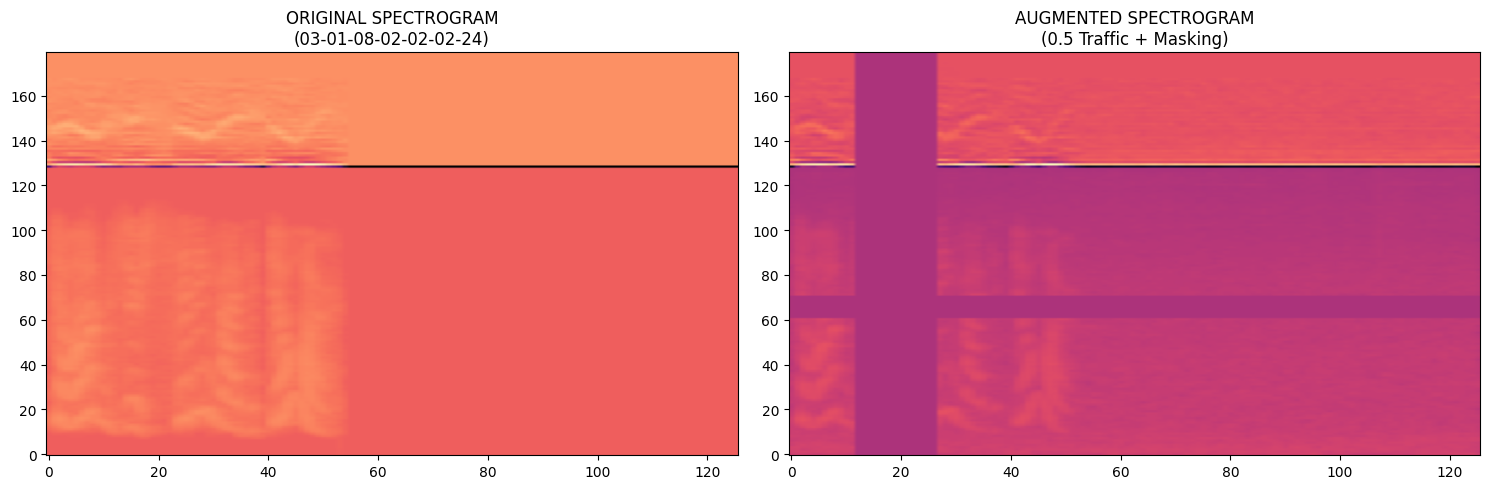

🔊 LISTEN TO THE AUGMENTED OUTPUT:


In [5]:


# --- HARDCODED TARGET ---
base_name = "03-01-08-02-02-02-24"
processed_dir = "data/processed_spectrograms"
aug_wav_dir = "data/augmented_audio_files"

# 1. Load the Spectrogram Arrays
orig_npy = os.path.join(processed_dir, f"orig_{base_name}.npy")
aug_npy = os.path.join(processed_dir, f"aug_{base_name}.npy")

# 2. Plotting the Spectrograms Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if os.path.exists(orig_npy) and os.path.exists(aug_npy):
    # Original Plot
    axes[0].imshow(np.load(orig_npy), aspect='auto', origin='lower', cmap='magma')
    axes[0].set_title(f"ORIGINAL SPECTROGRAM\n({base_name})")
    
    # Augmented Plot
    axes[1].imshow(np.load(aug_npy), aspect='auto', origin='lower', cmap='magma')
    axes[1].set_title(f"AUGMENTED SPECTROGRAM\n(0.5 Traffic + Masking)")
else:
    print("Check your paths! The .npy files weren't found.")

plt.tight_layout()
plt.show()

# 3. Audio Players
# If you don't have a raw folder, we skip the 'original' audio player 
# and just show the augmented one that YOU created.
aug_wav_path = os.path.join(aug_wav_dir, f"aug_{base_name}.wav")

if os.path.exists(aug_wav_path):
    print("🔊 LISTEN TO THE AUGMENTED OUTPUT:")
    ipd.display(ipd.Audio(aug_wav_path))
else:
    print(f"Could not find: {aug_wav_path}")

In [6]:
# # running MLP Model
# with tf.device("/GPU:0"):
#     mlp_test_acc, mlp_val_accuracies = run_experiment(model_type='mlp')

In [7]:
# running CNN-LSTM Model

with tf.device("/GPU:0"):
    cnn_lstm_mean_val_accuracies, cnn_lstm_val_accuracies = run_experiment(model_type='cnn_lstm') 

2026-05-08 22:31:28.271500: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-08 22:31:28.271971: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-08 22:31:28.271980: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1778275888.273022 3968948 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778275888.273576 3968948 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Test Set: 576 files.
Generated 5 Balanced Folds for Cross-Validation.

STARTING FOLD 1/5
STARTING CNN TRAINING


2026-05-08 22:31:32.372426: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch 01: Train Acc: 0.1270 | Val Acc: 0.1320 | Loss: 2.0670
Epoch 10: Train Acc: 0.1808 | Val Acc: 0.1905 | Loss: 2.0009
Epoch 20: Train Acc: 0.2600 | Val Acc: 0.2814 | Loss: 1.9111
Epoch 30: Train Acc: 0.3274 | Val Acc: 0.2727 | Loss: 1.8049


KeyboardInterrupt: 